In [1]:
from datetime import datetime, date
import pandas as pd
import itertools
from finrl.agents.elegantrl.models import DRLAgent
from enum import StrEnum, auto
from finrl.meta.data_processor import DataProcessor
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from stable_baselines3.common.logger import configure
from finrl.meta.env_stock_trading.env_forex_price_trailing import ForexPriceTrailingEnv
%matplotlib inline

In [2]:
class Currency(StrEnum):
    USD = auto()
    EUR = auto()
    JPY = auto()
    GBP = auto()
    AUD = auto()
    CAD = auto()
    CHF = auto()
    NZD = auto()
    CNY = auto()

In [3]:
start_date: date = date(2010, 1, 1)
end_date: date = date(2020, 1, 1)

majors = [
    "EURUSD=X","USDJPY=X","GBPUSD=X",
    "AUDUSD=X","USDCAD=X","USDCHF=X","NZDUSD=X"
]

# 2) Top non-USD crosses
crosses = [
    "EURGBP=X","EURJPY=X","GBPJPY=X","AUDJPY=X",
    "CADJPY=X","EURAUD=X","EURCAD=X","EURCHF=X",
    "GBPCHF=X","AUDCAD=X","NZDJPY=X","NZDCAD=X"
]

# 3) Key CNY pairs
cny_pairs = [
    "USDCNY=X","EURCNY=X","JPY CNY=X".replace(" ",""),  # -> "JPYCNY=X"
    "GBPCNY=X","AUDCNY=X","CADCNY=X","CHFCNY=X","NZDCNY=X"
]

# 4) Stitch together, then take the first 20 unique
all_tickers = majors + crosses + cny_pairs
# remove any duplicates and slice to 20
seen = set()
forex_ticks: tuple[str, ...] = tuple(
    t for t in all_tickers
    if not (t in seen or seen.add(t))
)
len(forex_ticks)

27

In [4]:
yfd = YahooDownloader(start_date=str(start_date), end_date=str(end_date), ticker_list=forex_ticks)
yfd

In [5]:
df = yfd.fetch_data()
df

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (70305, 8)


Price,date,close,high,low,open,volume,tic,day
0,2010-01-01,0.945120,0.945720,0.944000,0.945510,0,AUDCAD=X,4
1,2010-01-01,6.009700,6.037000,6.003100,6.036400,0,AUDCNY=X,4
2,2010-01-01,83.449997,83.602997,83.202003,83.463997,0,AUDJPY=X,4
3,2010-01-01,0.898473,0.898473,0.897827,0.898311,0,AUDUSD=X,4
4,2010-01-01,6.397100,6.397300,6.386700,6.386700,0,CADCNY=X,4
...,...,...,...,...,...,...,...,...
70300,2019-12-31,0.673478,0.675621,0.672088,0.673559,0,NZDUSD=X,1
70301,2019-12-31,1.306060,1.306080,1.295310,1.305800,0,USDCAD=X,1
70302,2019-12-31,0.968630,0.969680,0.964500,0.968640,0,USDCHF=X,1
70303,2019-12-31,6.985700,6.985900,6.957500,6.985700,0,USDCNY=X,1


In [6]:
def add_fx_features_for_tick(g: pd.DataFrame) -> pd.DataFrame:
    g["close_prev"] = g.close.shift(1)
    g["high_prev"] = g.high.shift(1)
    g["low_prev"] = g.low.shift(1)

    g["x1"] = (g.close - g.close_prev) / g.close_prev
    g["x2"] = (g.high - g.high_prev) / g.high_prev
    g["x3"] = (g.low - g.low_prev) / g.low_prev
    g["x4"] = (g.high - g.close) / g.close
    g["x5"] = (g.close - g.low) / g.close
    return g

def add_fx_features(df: pd.DataFrame, tic_col: str = "tic") -> pd.DataFrame:
    df_with_features = (
        df
        .groupby(tic_col, group_keys=False)
        .apply(add_fx_features_for_tick)
        .drop(columns=["close_prev", "high_prev", "low_prev"])
        .fillna(0)
    )
    return df_with_features

In [7]:
df_features = add_fx_features(df)
df_features

/var/folders/23/n0prkghs6v94ssbsv_9xq74c0000gn/T/ipykernel_58178/2277383529.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_fx_features_for_tick)


Price,date,close,high,low,open,volume,tic,day,x1,x2,x3,x4,x5
0,2010-01-01,0.945120,0.945720,0.944000,0.945510,0,AUDCAD=X,4,0.000000,0.000000,0.000000,0.000635,0.001185
1,2010-01-01,6.009700,6.037000,6.003100,6.036400,0,AUDCNY=X,4,0.000000,0.000000,0.000000,0.004543,0.001098
2,2010-01-01,83.449997,83.602997,83.202003,83.463997,0,AUDJPY=X,4,0.000000,0.000000,0.000000,0.001833,0.002972
3,2010-01-01,0.898473,0.898473,0.897827,0.898311,0,AUDUSD=X,4,0.000000,0.000000,0.000000,0.000000,0.000718
4,2010-01-01,6.397100,6.397300,6.386700,6.386700,0,CADCNY=X,4,0.000000,0.000000,0.000000,0.000031,0.001626
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70300,2019-12-31,0.673478,0.675621,0.672088,0.673559,0,NZDUSD=X,1,0.004229,0.002703,0.002204,0.003182,0.002063
70301,2019-12-31,1.306060,1.306080,1.295310,1.305800,0,USDCAD=X,1,-0.000979,-0.001743,-0.007653,0.000015,0.008231
70302,2019-12-31,0.968630,0.969680,0.964500,0.968640,0,USDCHF=X,1,-0.005217,-0.004435,-0.003101,0.001084,0.004264
70303,2019-12-31,6.985700,6.985900,6.957500,6.985700,0,USDCNY=X,1,-0.001301,-0.001272,-0.002766,0.000029,0.004037


In [ ]:
# df = pd.read_csv("trailing_histories/GBPJPY=X_20250623T202458Z.csv")

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline

plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df['date']), df['close'], label='Close')
plt.plot(pd.to_datetime(df['date']), df['agent_price'], label='Agent Price', linestyle='--')
plt.fill_between(
    pd.to_datetime(df['date']),
    df['upper'],
    df['lower'],
    color='gray',
    alpha=0.3,
    label='Upper/Lower'
)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.title('Close, Agent, Upper, and Lower Prices')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [18]:
from elegantrl.train.config import Config
from elegantrl.train.run import train_agent  # the usual entrypoint
from elegantrl.agents import AgentDiscreteA2C
import os
%matplotlib inline

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
window = 16

# 1) Build the Config
cfg = Config(
    agent_class=AgentDiscreteA2C,                
    env_class=ForexPriceTrailingEnv,
    env_args={
        'env_name':     'ForexTrail',    # just for naming/saving
        'num_envs':     1,               # single-env rollout\\
        # 'env_num':      1,
        'max_step':     2000,            # EP_LEN in your code
        'state_dim':    5 * window + 1,    # obs-dimension
        'action_dim':   3,               # Discrete(3)
        'if_discrete':  True,
        # any other init kwargs your env needs:
        "episode_len": 1000,
        "alpha_trail": 0.7,
        "alpha_pnl": 1.0,
        "alpha_fee": 0.8,
        'full_df':      df_features,
        'window':       16,
        'margin':       0.02,
        'step_frac':    0.1,
        "pick_new_pair_every": 700,
        "live_plot": True
    }
)

# 2) Tweak evaluation settings
cfg.eval_per_step = 2000     # “gap” between successive evaluations (in total training steps) 
cfg.eval_times    = 3     # # of episodes to run when evaluating, then average their returns
cfg.gamma = 0.999
cfg.break_step = 1e7

# 3) Kick off training + periodic eval
train_agent(cfg, if_single_process=True)

KeyboardInterrupt: 

In [ ]:
agent = AgentDiscreteA2C(net_dims=[128, 128], state_dim=5 * window + 1, action_dim=3)  
agent

In [ ]:
cfg.cwd

'./ForexTrail_DiscreteA2C_0'

In [ ]:
# agent.save_or_load_agent(cfg.cwd + '/actor__000000030720.pt', if_save=False)
# 2) Point it at the saved .pt files
#    (assumes they live under cfg.cwd)
# actor_path  = cfg.cwd + '/actor.pt'
# critic_path = cfg.cwd + '/critic.pt'
# agent.load_or_resume_with_path(actor_path, critic_path)

In [ ]:
import torch
# 1) Load the state dict
model = torch.load(cfg.cwd + '/actor__000000030720.pt', map_location='cpu', weights_only=False)
model

ActorDiscretePPO(
  (net): Sequential(
    (0): Linear(in_features=81, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
  (soft_max): Softmax(dim=-1)
)

In [ ]:
model.net(torch.zeros(1, 5 * window + 1))  # should return a tensor of shape (1, 3)

tensor([[ 0.3268, -0.2185, -0.1263]])

In [ ]:
agent.act.state_dict

<bound method Module.state_dict of ActorDiscretePPO(
  (net): Sequential(
    (0): Linear(in_features=81, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
  (soft_max): Softmax(dim=-1)
)>

In [ ]:
env_args={
    'full_df':      df_features,
    'window':       16,
    'margin':       0.02,
    'step_frac':    0.1,
    "pick_new_pair_every": 30000,
}

test_env=ForexPriceTrailingEnv(**env_args)

In [ ]:
test_env.df

Price,date,close,high,low,open,volume,tic,day,x1,x2,x3,x4,x5
0,2010-01-04,6.8169,6.8169,6.8169,6.8169,0,USDCNY=X,0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2010-01-05,6.8170,6.8170,6.8170,6.8170,0,USDCNY=X,1,0.000015,0.000015,0.000015,0.000000,0.000000
2,2010-01-06,6.8183,6.8183,6.8170,6.8170,0,USDCNY=X,2,0.000191,0.000191,0.000000,0.000000,0.000191
3,2010-01-07,6.8178,6.8183,6.8178,6.8183,0,USDCNY=X,3,-0.000073,0.000000,0.000117,0.000073,0.000000
4,2010-01-08,6.8175,6.8180,6.8175,6.8180,0,USDCNY=X,4,-0.000044,-0.000044,-0.000044,0.000073,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2596,2019-12-25,7.0064,7.0071,6.9815,7.0064,0,USDCNY=X,2,-0.000770,-0.000856,-0.002172,0.000100,0.003554
2597,2019-12-26,6.9883,7.0018,6.9854,6.9883,0,USDCNY=X,3,-0.002583,-0.000756,0.000559,0.001932,0.000415
2598,2019-12-27,6.9963,7.0001,6.9886,6.9963,0,USDCNY=X,4,0.001145,-0.000243,0.000458,0.000543,0.001101
2599,2019-12-30,6.9948,6.9948,6.9768,6.9948,0,USDCNY=X,0,-0.000214,-0.000757,-0.001688,0.000000,0.002573


In [ ]:
obs, _ = test_env.reset()

In [ ]:
import torch
done = False
truncated = False
actions = []
rewards = []
agent_prices = []

while not done and not truncated:
    action = agent.act(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
    action = action.detach().cpu().numpy().item()
    actions.append(action)
    agent_prices.append(test_env.agent_price)
    obs, reward, done, truncated, info = test_env.step(action)
    rewards.append(reward)
    print(f"Action: {action}, Reward: {reward}, Done: {done}, Truncated: {truncated}")

Action: 1, Reward: 0.3, Done: False, Truncated: False
Action: 1, Reward: 0.2868010191447411, Done: False, Truncated: False
Action: 1, Reward: 0.2948171337873677, Done: False, Truncated: False
Action: 1, Reward: 0.28632967947258764, Done: False, Truncated: False
Action: 1, Reward: 0.2978807820284925, Done: False, Truncated: False
Action: 1, Reward: 0.29011598456711085, Done: False, Truncated: False
Action: 1, Reward: 0.2927035563008007, Done: False, Truncated: False
Action: 1, Reward: 0.29764564128150767, Done: False, Truncated: False
Action: 1, Reward: 0.2586759147542298, Done: False, Truncated: False
Action: 1, Reward: 0.29082139345140445, Done: False, Truncated: False
Action: 1, Reward: 0.2931673909821394, Done: False, Truncated: False
Action: 1, Reward: 0.27145209870294834, Done: False, Truncated: False
Action: 1, Reward: 0.2645934514374524, Done: False, Truncated: False
Action: 1, Reward: 0.25322716843243126, Done: False, Truncated: False
Action: 1, Reward: 0.288688331120919, Done:

In [ ]:
[a for a in actions if a == -1]

[]

In [ ]:
from elegantrl.train.run import train_agent
from elegantrl.train.config import Config
from elegantrl.agents import AgentA2C

# 1) build your env (single copy is fine for on‐policy A2C)
env = ForexPriceTrailingEnv(
    df_features[df_features.tic == forex_ticks[0]], 
    window=16, 
    margin=0.01,
    step_frac=0.01,
    episode_len=1000
)

# 2) pack into ElegantRL’s Arguments
args = Config(
    agent_class=AgentA2C,
    env_class=env,
    # env_name="ForexPriceTrailingEnv",
    # reward_scale=1.0,     # if you want to scale down large rewards
    # gamma=0.99,
    env_args={"max_step": env.max_step, "env_name": "ForexPriceTrailingEnv"},
    # max_step=env.max_step,
    # batch_size=32,        # how many steps per update
    # learning_rate=2e-4,
    # eval_times=3,
    # eval_gap=5_000,       # evaluate every 5000 env steps
)

# 3) launch training
train_agent(args)

KeyError: 'state_dim'

In [ ]:
dp.tech_indicator_list = technical_indicator_list
price_array, tech_array, turbulence_array = dp.df_to_array(data, False)
env_config = {
    "price_array": price_array,
    "tech_array": tech_array,
    "turbulence_array": turbulence_array,
    "if_train": True,
}

In [ ]:
agent_erl = DRLAgent(ForexPriceTrailingEnv, price_array, tech_array, None)

In [ ]:
agent_erl.train_model('ddpg', total_timesteps=50_000)

TypeError: DRLAgent.train_model() missing 1 required positional argument: 'cwd'

In [ ]:
env_context = {
    "window": 16,
    "margin": 0.01,
    "step_frac": 0.1,
    "fee": 0.0001,
    "alpha_trail": 0.99,
    "alpha_pnl": 0.95,
    "alpha_fee": 1.0,
    "episode_len": 4000,
    "live_plot": False
}

pair = df_features.tic.unique().tolist()[0]
test_env = ForexPriceTrailingEnv(df_features[df_features.tic == pair], **env_context)

In [ ]:
env_context = {
    "window": 16,
    "margin": 0.01,
    "step_frac": 0.1,
    "fee": 0.0001,
    "alpha_trail": 0.99,
    "alpha_pnl": 0.95,
    "alpha_fee": 1.0,
    "episode_len": 4000,
    "live_plot": False
}

pair = df_features.tic.unique().tolist()[0]
env_live = ForexPriceTrailingEnv(df_features[df_features.tic == pair], **env_context)
vec_env = DummyVecEnv([lambda: env_live])
algorithms = ['a2c', 'ppo']
agent = DRLAgent(env=vec_env)

TypeError: DRLAgent.__init__() missing 3 required positional arguments: 'price_array', 'tech_array', and 'turbulence_array'

In [ ]:
pairs = df_features.tic.unique().tolist()
env_live2 = ForexPriceTrailingEnv(df_features[df_features.tic == pairs[0]], **env_context)
vec_env2 = DummyVecEnv([lambda: env_live2])
agent = DRLAgent(env=vec_env2)

In [ ]:
model_params = dict(learning_rate=0.0003, gamma=0.95)
trained_agent = agent.train_model(
    model=agent.get_model('a2c', **model_params), 
    tb_log_name='a2c_multi_env',       
    total_timesteps=50000,
)

TypeError: DRLAgent.get_model() got an unexpected keyword argument 'learning_rate'

In [ ]:
env_live2 = ForexPriceTrailingEnv(df_features[df_features.tic == pairs[1]], **env_context)
vec_env2 = DummyVecEnv([lambda: env_live2])
new_agent = DRLAgent(env=vec_env2)

trained_agent = new_agent.train_model(
    model=trained_agent, 
    tb_log_name='a2c_multi_env',       
    total_timesteps=50000,
)

--------------------------------------
| time/                 |            |
|    fps                | 1402       |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -1.05      |
|    explained_variance | 1.79e-07   |
|    learning_rate      | 0.0007     |
|    n_updates          | 10099      |
|    policy_loss        | -5.62e+04  |
|    reward             | -20925.13  |
|    reward_max         | -20925.13  |
|    reward_mean        | -20925.143 |
|    reward_min         | -20925.152 |
|    value_loss         | 4.67e+09   |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 1421       |
|    iterations         | 200        |
|    time_elapsed       | 0          |
|    total_timesteps    | 1000       |
| train/                |            |
|    entropy_loss       |

In [ ]:
env_live2 = ForexPriceTrailingEnv(df_features[df_features.tic == pairs[2]], **env_context)
vec_env2 = DummyVecEnv([lambda: env_live2])
new_agent = DRLAgent(env=vec_env2)

trained_agent = new_agent.train_model(
    model=trained_agent, 
    tb_log_name='a2c_multi_env',       
    total_timesteps=50000,
)

--------------------------------------
| time/                 |            |
|    fps                | 1390       |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -1.07      |
|    explained_variance | 0          |
|    learning_rate      | 0.0007     |
|    n_updates          | 20099      |
|    policy_loss        | 11.2       |
|    reward             | 0.58588666 |
|    reward_max         | 0.58588666 |
|    reward_mean        | 0.08481717 |
|    reward_min         | -1.048851  |
|    value_loss         | 161        |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 1370       |
|    iterations         | 200        |
|    time_elapsed       | 0          |
|    total_timesteps    | 1000       |
| train/                |            |
|    entropy_loss       |

KeyboardInterrupt: 

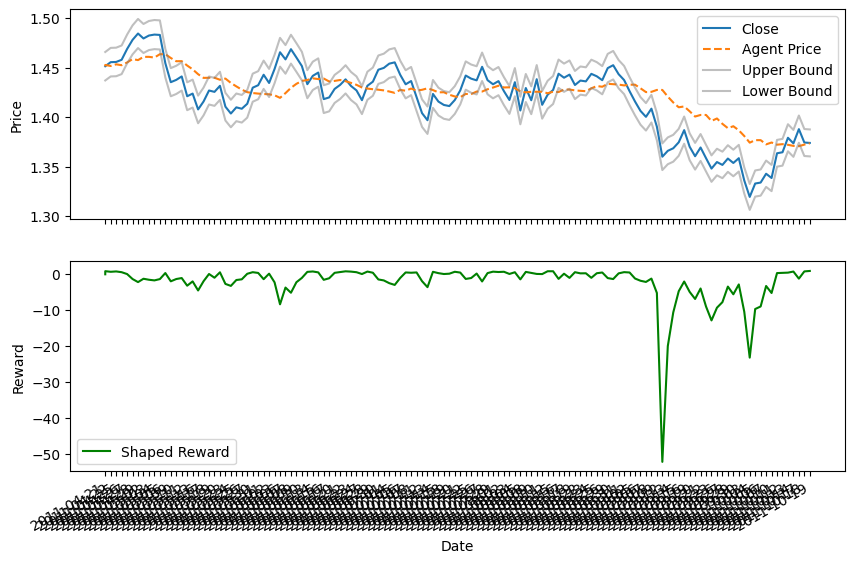

In [ ]:
pair = df_features.tic.unique().tolist()[0]
eval_context = env_context
eval_context["live_plot"] = True
env_eval = ForexPriceTrailingEnv(df_features[df_features.tic == pair], **eval_context)
pair
obs, _ = env_eval.reset()
done, truncated = False, False
while not (done or truncated):
    action, _ = trained_agent.predict(obs)
    obs, rewards, done, truncated, info = env_eval.step(action)
    

In [ ]:
envs = [
    (lambda pair=p: ForexPriceTrailingEnv(
        df_features[df_features.tic == pair].copy(),
        **env_context
    ))
    for p in df_features.tic.unique()
]

vectorized_env = SubprocVecEnv(
    envs,
    start_method="fork"
)

In [ ]:
multi_env_agent = DRLAgent(env=vectorized_env)

In [ ]:
trained_multi_env_agent = multi_env_agent.train_model(
    model=multi_env_agent.get_model('a2c'), 
    tb_log_name='a2c_multi_env',       
    total_timesteps=50000,
)

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
--------------------------------------
| time/                 |            |
|    fps                | 2311       |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 1500       |
| train/                |            |
|    entropy_loss       | -1.1       |
|    explained_variance | 0.000791   |
|    learning_rate      | 0.0007     |
|    n_updates          | 99         |
|    policy_loss        | -270       |
|    reward             | 0.27       |
|    reward_max         | 0.9230622  |
|    reward_mean        | -402.8295  |
|    reward_min         | -1909.2776 |
|    value_loss         | 2.43e+05   |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 2442       |
|    iterations         | 200        |
|    time_elapsed       | 1          |
|    total_timesteps    | 30

In [ ]:
pair = df_features.tic.unique().tolist()[0]
eval_context = env_context
eval_context["live_plot"] = True
env_eval = ForexPriceTrailingEnv(df_features[df_features.tic == pair], **eval_context)
pair

'EURUSD=X'

KeyboardInterrupt: 

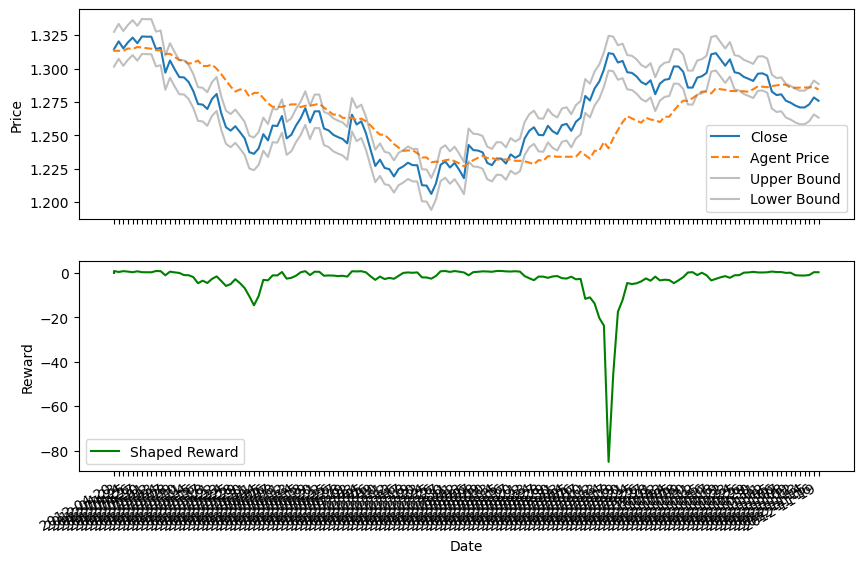

In [ ]:
obs, _ = env_eval.reset()
done, truncated = False, False
while not (done or truncated):
    action, _ = trained_multi_env_agent.predict(obs)
    obs, rewards, done, truncated, info = env_eval.step(action)
    


In [ ]:
trained_a2c = agent.train_model(
    model=agent.get_model('a2c'), 
    tb_log_name='a2c',       
    total_timesteps=50000,
)

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
--------------------------------------
| time/                 |            |
|    fps                | 1478       |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -1.1       |
|    explained_variance | -0.000888  |
|    learning_rate      | 0.0007     |
|    n_updates          | 99         |
|    policy_loss        | -177       |
|    reward             | -9.712668  |
|    reward_max         | -9.712668  |
|    reward_mean        | -15.748804 |
|    reward_min         | -24.29401  |
|    value_loss         | 3.18e+04   |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 1482       |
|    iterations         | 200        |
|    time_elapsed       | 0          |
|    total_timesteps    | 10

In [ ]:
models = {algo: agent.get_model(algo) for algo in algorithms}
models_trained = {}
for algo in algorithms:
    print(f"Training with {algo}")
    model = models[algo]
    tmp_path = RESULTS_DIR + f'/{algo}'
    new_logger_algo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model.set_logger(new_logger_algo)
    models_trained[algo] = agent.train_model(
        model=models_trained.get(algo, model), 
        tb_log_name=algo,       
        total_timesteps=50000,
    )

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
Using cpu device
Training with a2c
Logging to results/a2c
--------------------------------------
| time/                 |            |
|    fps                | 1498       |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -1.09      |
|    explained_variance | 0.0247     |
|    learning_rate      | 0.0007     |
|    n_updates          | 99         |
|    policy_loss        | 3.39       |
|    reward             | 0.56287676 |
|    reward_max         | 0.886271   |
|    reward_mean        | 0.5749606  |
|    reward_min         | 0.20183796 |
|    value_loss         | 8.6        |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fp

KeyboardInterrupt: 

In [ ]:
models_trained["a2c"].env.envs[0]._hist_agent == models_trained["ppo"].env.envs[0]._hist_agent

NameError: name 'models_trained' is not defined

In [ ]:
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.config import RESULTS_DIR
from stable_baselines3.common.logger import configure

# Assume df_features, env_context, and ForexPriceTrailingEnv are already defined

# 1) Prepare
pair_list = df_features.tic.unique().tolist()
algorithms = ['a2c', 'ppo']
train_timesteps = 50000

# Storage for histories
histories = {algo: {} for algo in algorithms}

# 2) Loop over algorithms and pairs
for algo in algorithms:
    print(f"\n=== Algorithm: {algo.upper()} ===")
    for pair in pair_list:
        print(f"Training on pair: {pair}")
        # Build environment for this pair
        df_pair = df_features[df_features.tic == pair]
        env_live = ForexPriceTrailingEnv(df_pair, live_plot=False, **env_context)
        vec_env = DummyVecEnv([lambda: env_live])
        
        # Create and configure agent
        agent = DRLAgent(env=vec_env)
        model = agent.get_model(algo)
        tmp_path = f"{RESULTS_DIR}/{algo}_{pair}"
        new_logger = configure(tmp_path, ["stdout", "csv", "tensorboard"])
        model.set_logger(new_logger)
        
        # Train
        trained_model = agent.train_model(
            model=model,
            tb_log_name=f"{algo}_{pair}",
            total_timesteps=train_timesteps
        )
        
        # After training, grab the environment's recorded histories
        histories[algo][pair] = {
            'dates':         env_live._hist_dates.copy(),
            'closes':        env_live._hist_closes.copy(),
            'agent_prices':  env_live._hist_agent.copy(),
            'rewards':       env_live._hist_rewards.copy(),
            'upper_bounds':  env_live._hist_upper.copy(),
            'lower_bounds':  env_live._hist_lower.copy(),
        }

# 3) Accessing results example
# For PPO on EURUSD:




=== Algorithm: A2C ===
Training on pair: EURUSD=X
{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
Logging to results/a2c_EURUSD=X


---------------------------------------
| time/                 |             |
|    fps                | 1114        |
|    iterations         | 100         |
|    time_elapsed       | 0           |
|    total_timesteps    | 500         |
| train/                |             |
|    entropy_loss       | -1.09       |
|    explained_variance | -0.354      |
|    learning_rate      | 0.0007      |
|    n_updates          | 99          |
|    policy_loss        | -0.0643     |
|    reward             | 0.034789376 |
|    reward_max         | 0.78237224  |
|    reward_mean        | 0.02258065  |
|    reward_min         | -1.1215783  |
|    value_loss         | 0.114       |
---------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 1241       |
|    iterations         | 200        |
|    time_elapsed       | 0          |
|    total_timesteps    | 1000       |
| train/                |            |
|    en

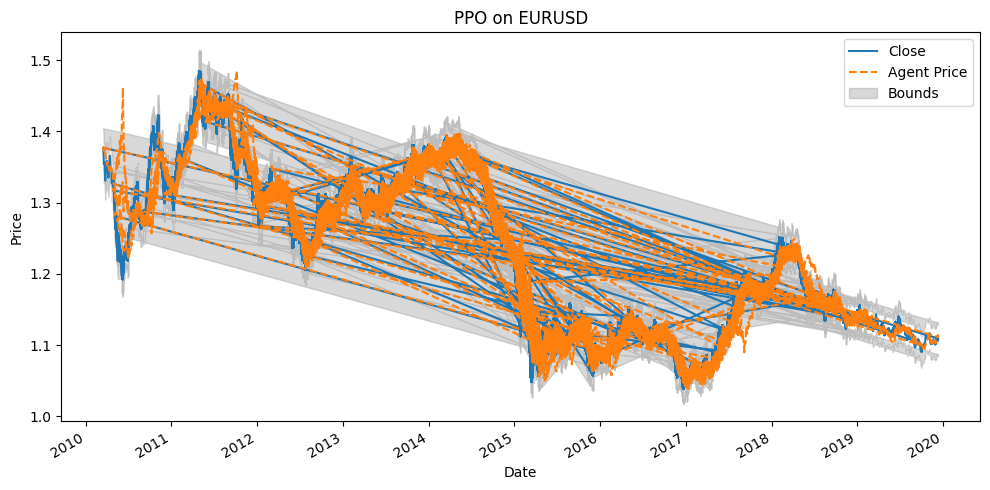

In [ ]:
eurusd_hist = histories['ppo']['EURUSD=X']
plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(eurusd_hist['dates']), eurusd_hist['closes'],       label='Close')
plt.plot(pd.to_datetime(eurusd_hist['dates']), eurusd_hist['agent_prices'], label='Agent Price', linestyle='--')
plt.fill_between(pd.to_datetime(eurusd_hist['dates']), eurusd_hist['upper_bounds'], eurusd_hist['lower_bounds'],
                 color='gray', alpha=0.3, label='Bounds')
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.title('PPO on EURUSD')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [ ]:
histories['ppo']['EURUSD=X']

{'dates': ['2013-12-09',
  '2013-12-09',
  '2013-12-10',
  '2013-12-11',
  '2013-12-12',
  '2013-12-13',
  '2013-12-16',
  '2013-12-17',
  '2013-12-18',
  '2013-12-19',
  '2013-12-20',
  '2013-12-23',
  '2013-12-24',
  '2013-12-25',
  '2013-12-26',
  '2013-12-27',
  '2013-12-30',
  '2013-12-31',
  '2014-01-01',
  '2014-01-02',
  '2014-01-03',
  '2014-01-06',
  '2014-01-07',
  '2014-01-08',
  '2014-01-09',
  '2014-01-10',
  '2014-01-13',
  '2014-01-14',
  '2014-01-15',
  '2014-01-16',
  '2014-01-17',
  '2014-01-20',
  '2014-01-21',
  '2014-01-22',
  '2014-01-23',
  '2014-01-24',
  '2014-01-27',
  '2014-01-28',
  '2014-01-29',
  '2014-01-30',
  '2014-01-31',
  '2014-02-03',
  '2014-02-04',
  '2014-02-05',
  '2014-02-06',
  '2014-02-07',
  '2014-02-10',
  '2014-02-11',
  '2014-02-12',
  '2014-02-13',
  '2014-02-14',
  '2014-02-17',
  '2014-02-18',
  '2014-02-19',
  '2014-02-20',
  '2014-02-21',
  '2014-02-24',
  '2014-02-25',
  '2014-02-26',
  '2014-02-27',
  '2014-02-28',
  '2014-03-03',

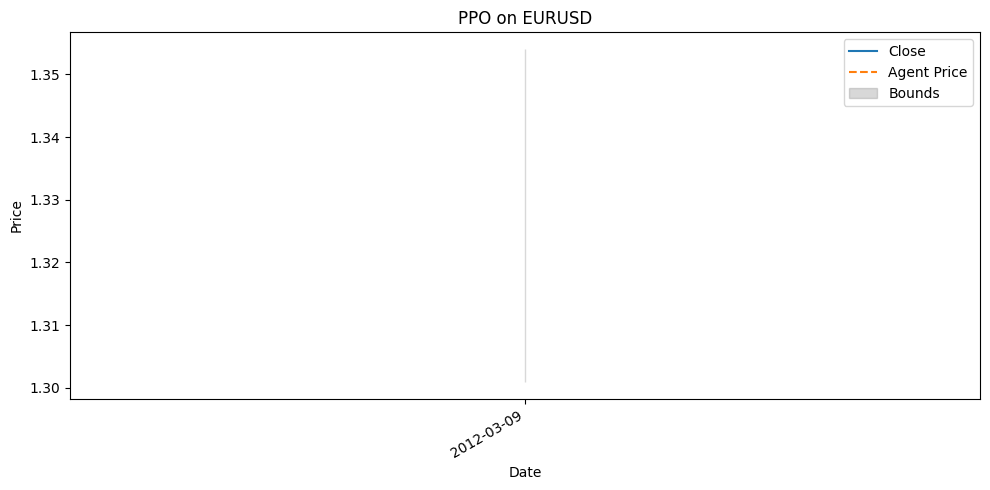

In [ ]:
eurusd_hist = histories['a2c']['EURUSD=X']
plt.figure(figsize=(10,5))
plt.plot(eurusd_hist['dates'], eurusd_hist['closes'],       label='Close')
plt.plot(eurusd_hist['dates'], eurusd_hist['agent_prices'], label='Agent Price', linestyle='--')
plt.fill_between(eurusd_hist['dates'], eurusd_hist['upper_bounds'], eurusd_hist['lower_bounds'],
                 color='gray', alpha=0.3, label='Bounds')
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.title('PPO on EURUSD')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [ ]:
eurusd_hist = histories['ppo']['GBPUSD=X']
plt.figure(figsize=(10,5))
plt.plot(eurusd_hist['dates'], eurusd_hist['closes'],       label='Close')
plt.plot(eurusd_hist['dates'], eurusd_hist['agent_prices'], label='Agent Price', linestyle='--')
plt.fill_between(eurusd_hist['dates'], eurusd_hist['upper_bounds'], eurusd_hist['lower_bounds'],
                 color='gray', alpha=0.3, label='Bounds')
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.title('PPO on EURUSD')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()